# **AU2544013 - Hardi Makwana**
# **AU2544030 - Krisha Doshi**

# **Importing Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.impute import IterativeImputer
from imblearn.combine import SMOTETomek 
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA

# **Loading Dataset and Initial Separation**

In [2]:
df = pd.read_csv('MSME_Credit_Cleaned_PreImpute.csv')
X = df.drop(columns=['Enterprise_id', 'Label'])
y = df['Label']

# **3-WAY STRICT TRAIN-VAL-TEST SPLIT**

In [3]:
# Step A: 15% for the Test Set (Unseen)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Step B: Split remaining 85% into Train (70% of total) and Val (15% of total)
# 15 / 85 = 0.17647
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.17647, random_state=42, stratify=y_temp
)

print(f"Dataset Split Ratios:")
print(f"Train: {len(X_train)} ({len(X_train)/len(X):.0%})")
print(f"Val:   {len(X_val)} ({len(X_val)/len(X):.0%})")
print(f"Test:  {len(X_test)} ({len(X_test)/len(X):.0%})\n")

Dataset Split Ratios:
Train: 1194 (70%)
Val:   256 (15%)
Test:  257 (15%)



# **MICE Imputation**

In [4]:
print("--- Applying Strict Leakage-Free Imputation ---")

# 1. Separate Numeric and Categorical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

# 2. Initialize the winning Imputers (MICE for numbers, Mode for text)
num_imputer = IterativeImputer(max_iter=30, random_state=42)
cat_imputer = SimpleImputer(strategy='most_frequent')

# 3. FIT strictly on the Training Set, transform Train
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]), columns=numeric_cols, index=X_train.index)
X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[cat_cols]), columns=cat_cols, index=X_train.index)
X_train = pd.concat([X_train_num, X_train_cat], axis=1)

# 4. ONLY TRANSFORM the Validation and Test sets (No fitting!)
X_val_num = pd.DataFrame(num_imputer.transform(X_val[numeric_cols]), columns=numeric_cols, index=X_val.index)
X_val_cat = pd.DataFrame(cat_imputer.transform(X_val[cat_cols]), columns=cat_cols, index=X_val.index)
X_val = pd.concat([X_val_num, X_val_cat], axis=1)

X_test_num = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]), columns=numeric_cols, index=X_test.index)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=cat_cols, index=X_test.index)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

print("Imputation complete. Zero data leakage occurred.")

--- Applying Strict Leakage-Free Imputation ---
Imputation complete. Zero data leakage occurred.


--- Generating MICE Imputation Impact Graph ---


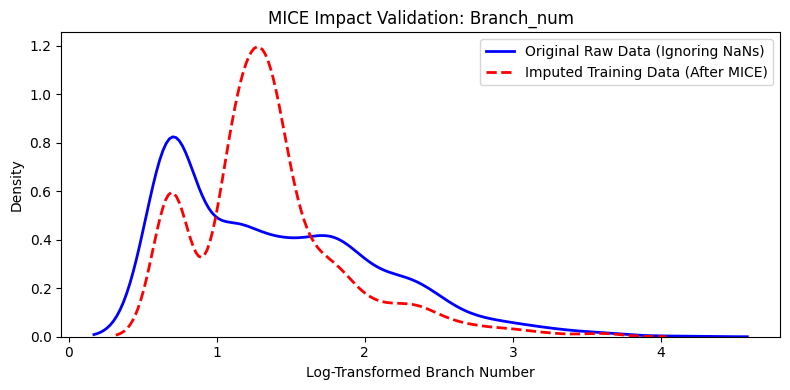

In [5]:
print("--- Generating MICE Imputation Impact Graph ---")

# Let's visualize the impact on 'Branch_num' since we know it had 44% missing values
sample_missing_col = 'Branch_num'

if sample_missing_col in X_train.columns and sample_missing_col in df.columns:
    plt.figure(figsize=(8, 4))
    
    # Plot original raw data from df (before any imputation)
    sns.kdeplot(df[sample_missing_col].dropna(), 
                label='Original Raw Data (Ignoring NaNs)', color='blue', linewidth=2)
    
    # Plot the newly imputed X_train data (After MICE)
    sns.kdeplot(X_train[sample_missing_col], 
                label='Imputed Training Data (After MICE)', color='red', linestyle='--', linewidth=2)
    
    plt.title(f'MICE Impact Validation: {sample_missing_col}', fontsize=12)
    plt.xlabel('Log-Transformed Branch Number')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Column not found for visualization.")

# **Visualizations (Training Data Only)**

--- Generating Visualizations ---


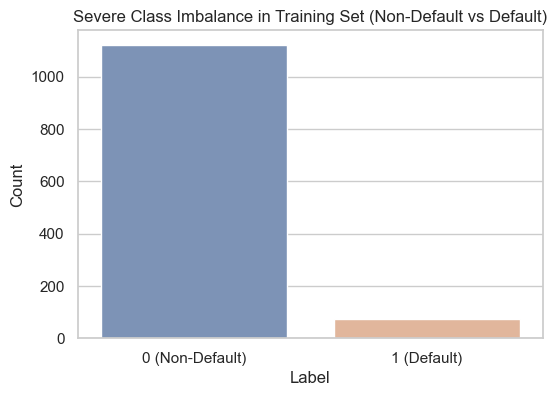

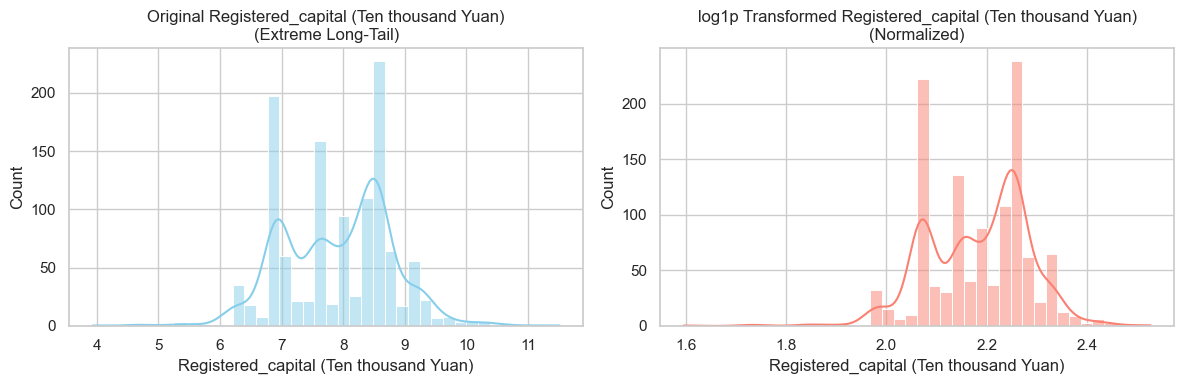

In [6]:
print("--- Generating Visualizations ---")
sns.set_theme(style="whitegrid")

# A. Class Imbalance Check
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, hue=y_train, palette=["#7491BF", "#ECB391"], legend=False)
plt.title('Severe Class Imbalance in Training Set (Non-Default vs Default)', fontsize=12)
plt.xticks([0, 1], ['0 (Non-Default)', '1 (Default)'])
plt.ylabel('Count')
plt.show()

# B. Skewness and Transformation Preview
skewed_col = 'Registered_capital (Ten thousand Yuan)'
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(X_train[skewed_col].dropna(), kde=True, color='skyblue', bins=40, ax=axes[0])
axes[0].set_title(f'Original {skewed_col}\n(Extreme Long-Tail)')

sns.histplot(np.log1p(X_train[skewed_col].dropna()), kde=True, color='salmon', bins=40, ax=axes[1])
axes[1].set_title(f'log1p Transformed {skewed_col}\n(Normalized)')
plt.tight_layout()
plt.show()

# **Dynamic Column Detection Logic**

In [7]:
# Instead of hardcoding, we analyze the data to decide the best encoding strategy
obj_cols = X_train.select_dtypes(include=['object']).columns

text_cols_for_tfidf = []
cat_cols_for_ohe = []

for col in obj_cols:
    # Heuristic: If strings contain spaces or multiple words, it is "Text"
    avg_words = X_train[col].dropna().apply(lambda x: len(str(x).split())).mean()
    if avg_words > 1.5:
        text_cols_for_tfidf.append(col)
    else:
        cat_cols_for_ohe.append(col)

print(f"Detected Text Columns (TF-IDF): {text_cols_for_tfidf}")
print(f"Detected Categorical Columns (OHE): {cat_cols_for_ohe}\n")

Detected Text Columns (TF-IDF): ['Enterprise_type', 'Sector']
Detected Categorical Columns (OHE): ['Province']



# **Custom Feature Engineering**

In [8]:
def engineer_features(data):
    df_eng = data.copy()
    
    # 1. Capture momentum in Legal actions
    legal_cols = [c for c in df_eng.columns if 'Legal_proceedings_num' in c]
    if legal_cols: df_eng['Total_Legal_5Y'] = df_eng[legal_cols].sum(axis=1)
        
    # 2. Aggregate Tax compliance
    tax_cols = [c for c in df_eng.columns if 'Overdue_tax_num' in c]
    if tax_cols: df_eng['Total_Tax_Overdue_3Y'] = df_eng[tax_cols].sum(axis=1)
        
    # 3. Aggregate Insurance snapshots (Digital Footprint)
    ins_cols = [c for c in df_eng.columns if 'insurance' in c.lower()]
    if ins_cols: df_eng['Total_Insurance_Contributions'] = df_eng[ins_cols].sum(axis=1)
            
    return df_eng

X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

# **TF-IDF Processing**

In [9]:
# We remove max_features=10 and use min_df=2 (must appear in at least 2 enterprises)
# to filter noise while keeping all statistically relevant keywords.
tfidf_models = {}

for col in text_cols_for_tfidf:
    tfidf = TfidfVectorizer(min_df=2, stop_words='english')
    
    # Fit strictly on train
    train_tfidf = tfidf.fit_transform(X_train[col].fillna('Unknown'))
    val_tfidf = tfidf.transform(X_val[col].fillna('Unknown'))
    test_tfidf = tfidf.transform(X_test[col].fillna('Unknown'))
    
    # Names of new features (e.g., EnterpriseType_limited)
    cols = [f"{col}_{word}" for word in tfidf.get_feature_names_out()]
    
    # Merge and Drop original
    X_train = pd.concat([X_train.drop(columns=[col]), pd.DataFrame(train_tfidf.toarray(), columns=cols, index=X_train.index)], axis=1)
    X_val = pd.concat([X_val.drop(columns=[col]), pd.DataFrame(val_tfidf.toarray(), columns=cols, index=X_val.index)], axis=1)
    X_test = pd.concat([X_test.drop(columns=[col]), pd.DataFrame(test_tfidf.toarray(), columns=cols, index=X_test.index)], axis=1)
    
    tfidf_models[col] = tfidf

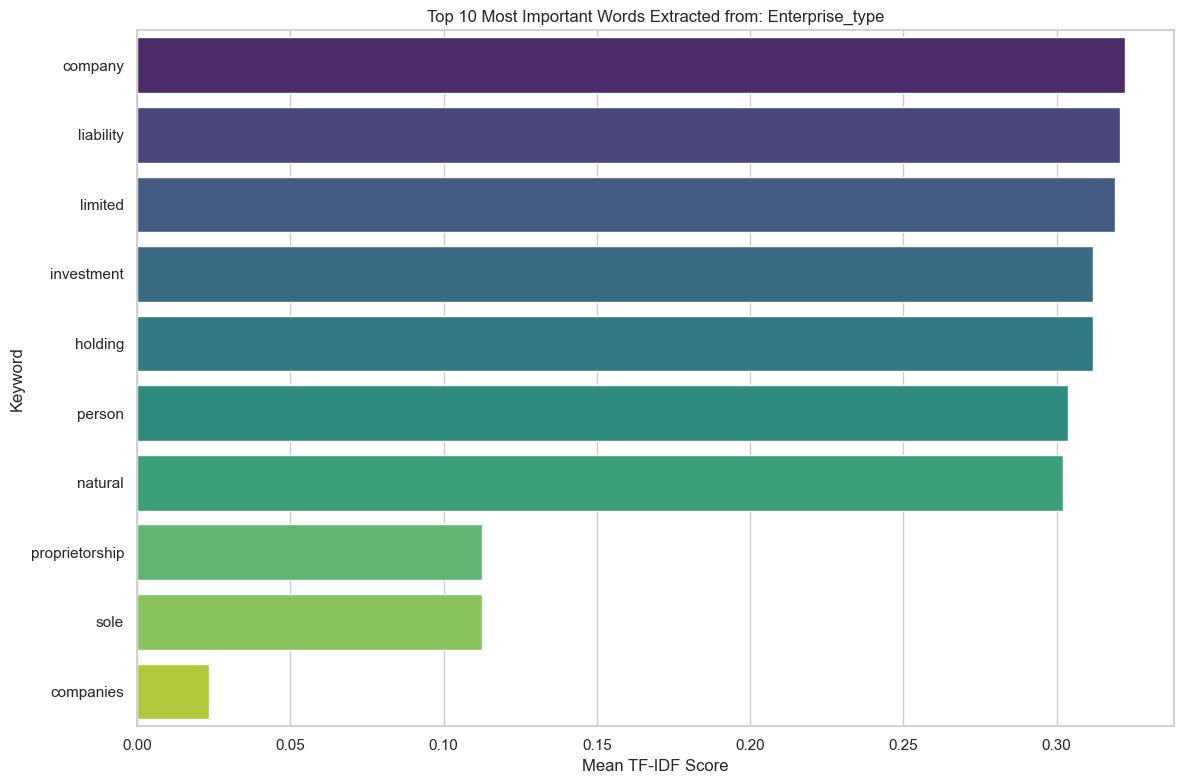

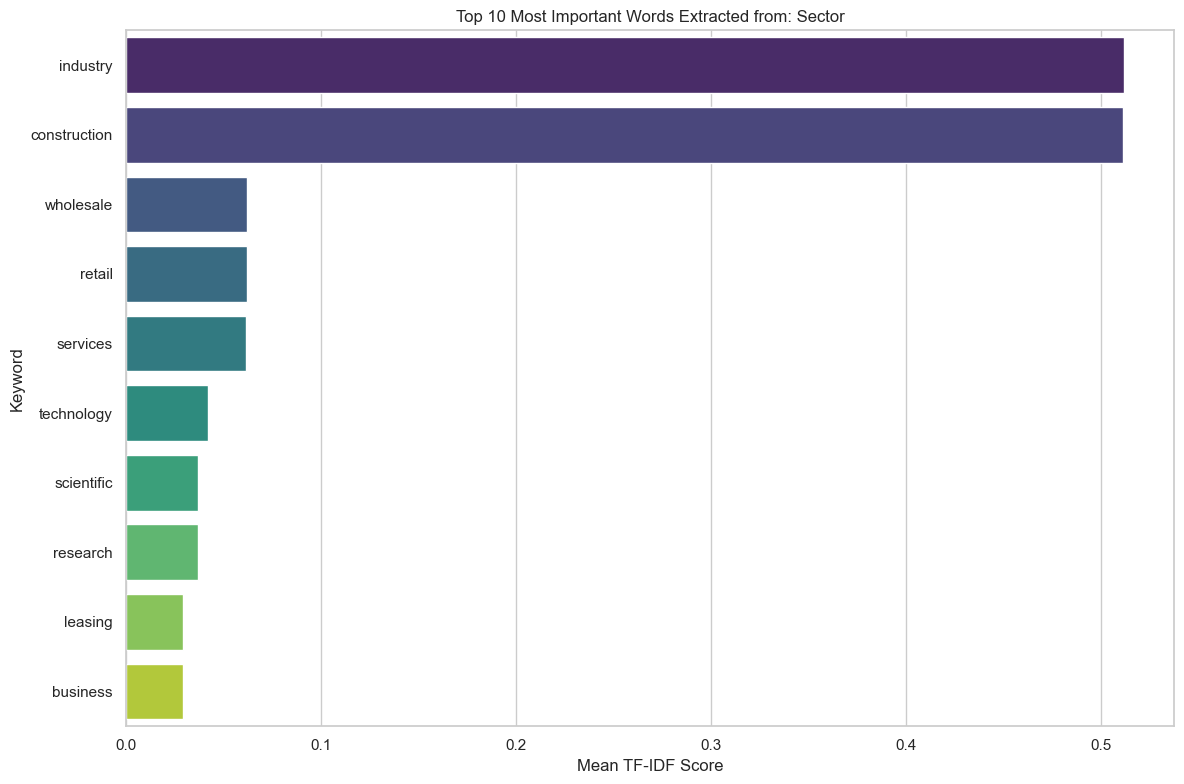

In [10]:
if text_cols_for_tfidf:
    for col in text_cols_for_tfidf:
        # Get all new TF-IDF columns for this text feature
        tfidf_feature_cols = [c for c in X_train.columns if c.startswith(f"{col}_")]
        
        # Calculate mean TF-IDF score for each word across all MSMEs
        mean_tfidf = X_train[tfidf_feature_cols].mean().sort_values(ascending=False).head(10)
        
        # Clean up labels for the plot (remove the column prefix)
        clean_labels = [name.replace(f"{col}_", "") for name in mean_tfidf.index]
        
        plt.figure(figsize=(12, 8))
        sns.barplot(x=mean_tfidf.values, y=clean_labels, palette='viridis')
        plt.title(f'Top 10 Most Important Words Extracted from: {col}', fontsize=12)
        plt.xlabel('Mean TF-IDF Score')
        plt.ylabel('Keyword')
        plt.tight_layout()
        plt.show()

# **One-Hot Encoding**

In [11]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = ohe.fit_transform(X_train[cat_cols_for_ohe])
ohe_val = ohe.transform(X_val[cat_cols_for_ohe])
ohe_test = ohe.transform(X_test[cat_cols_for_ohe])

ohe_cols = ohe.get_feature_names_out(cat_cols_for_ohe)

X_train = pd.concat([X_train.drop(columns=cat_cols_for_ohe), pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)], axis=1)
X_val = pd.concat([X_val.drop(columns=cat_cols_for_ohe), pd.DataFrame(ohe_val, columns=ohe_cols, index=X_val.index)], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_cols_for_ohe), pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)], axis=1)

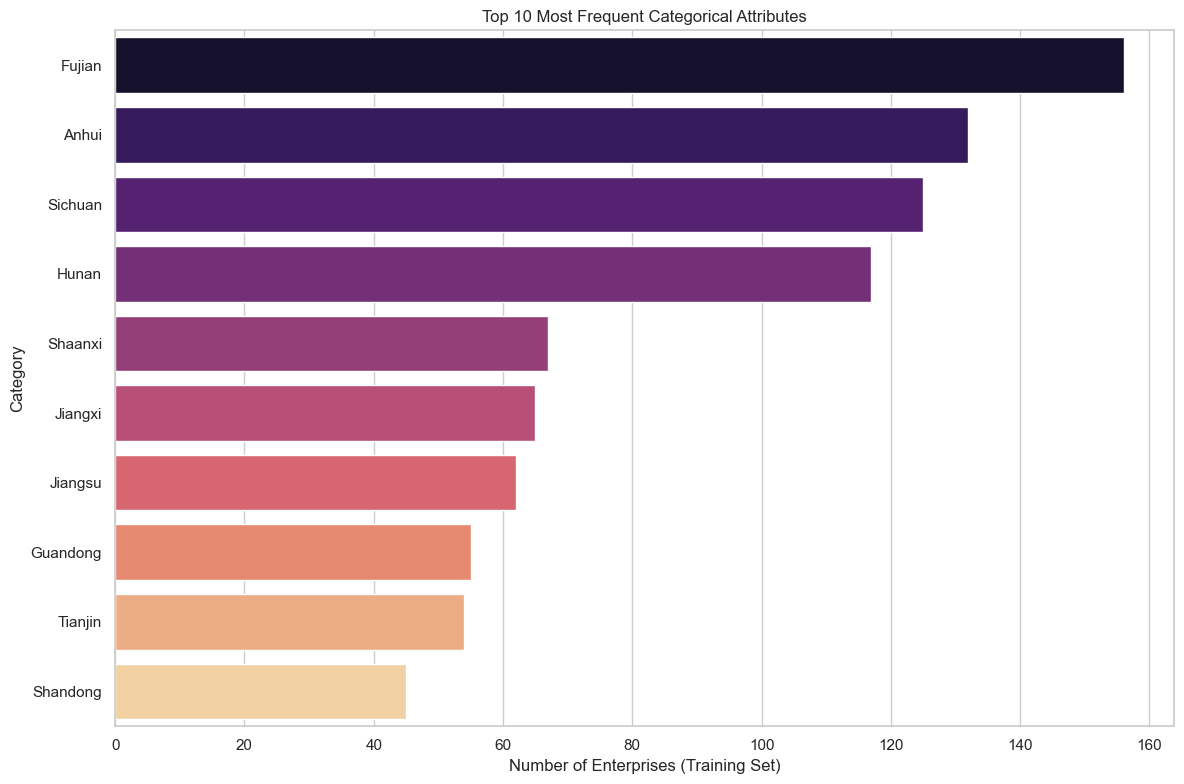

In [12]:
if len(ohe_cols) > 0:
    # Sum the OHE columns to get the total count of enterprises in each category
    cat_counts = X_train[ohe_cols].sum().sort_values(ascending=False).head(10)
    # Clean up names (e.g., 'Province_Sichuan' -> 'Sichuan')
    clean_cat_names = [name.split('_', 1)[-1] for name in cat_counts.index]
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=cat_counts.values, y=clean_cat_names, palette='magma')
    plt.title('Top 10 Most Frequent Categorical Attributes', fontsize=12)
    plt.xlabel('Number of Enterprises (Training Set)')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

# **Scaling**

In [13]:
scaler = StandardScaler()

# Fit on Train, transform Train
X_train_final = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

# Only transform Val and Test (No fitting!)
X_val_final = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_final = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Scaling complete. Data is ready for resampling!")

Scaling complete. Data is ready for resampling!


# **Comparing SMOTE-Tomek and ADASYN**

In [14]:
print("--- Diagnostic Imbalance Comparison ---")

# Method 1: ADASYN
ada = ADASYN(random_state=42)
X_train_ada, y_train_ada = ada.fit_resample(X_train_final, y_train)

# Method 2: SMOTETomek
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_final, y_train)

def evaluate_and_diagnose(X_tr, y_tr, X_v, y_v, name):
    # CRITICAL FIX: Using balanced_subsample and more trees
    model = RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample', random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_v)
    
    f1 = f1_score(y_v, preds)
    cm = confusion_matrix(y_v, preds)
    
    print(f"\nResults for {name}:")
    print(f"F1-Score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    # This shows: [[True Neg, False Pos], [False Neg, True Pos]]
    # If the bottom-right number is > 0, we caught a defaulter!
    
    return f1

f1_ada = evaluate_and_diagnose(X_train_ada, y_train_ada, X_val_final, y_val, "ADASYN")
f1_smt = evaluate_and_diagnose(X_train_smt, y_train_smt, X_val_final, y_val, "SMOTETomek")

--- Diagnostic Imbalance Comparison ---

Results for ADASYN:
F1-Score: 0.0000
Confusion Matrix:
[[239   2]
 [ 15   0]]

Results for SMOTETomek:
F1-Score: 0.0000
Confusion Matrix:
[[240   1]
 [ 15   0]]


# **t-SEN**

In [15]:
print("\n--- Generating t-SNE Scatter Plots for Resampling ---")
print("Calculating t-SNE embeddings")

# CALCULATE t-SNE EMBEDDINGS
# Initialize t-SNE 
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')

# t-SNE must be fit on ALL datasets independently
X_tsne_orig = tsne.fit_transform(X_train_final) 
X_tsne_ada = tsne.fit_transform(X_train_ada)
X_tsne_smt = tsne.fit_transform(X_train_smt)



--- Generating t-SNE Scatter Plots for Resampling ---
Calculating t-SNE embeddings


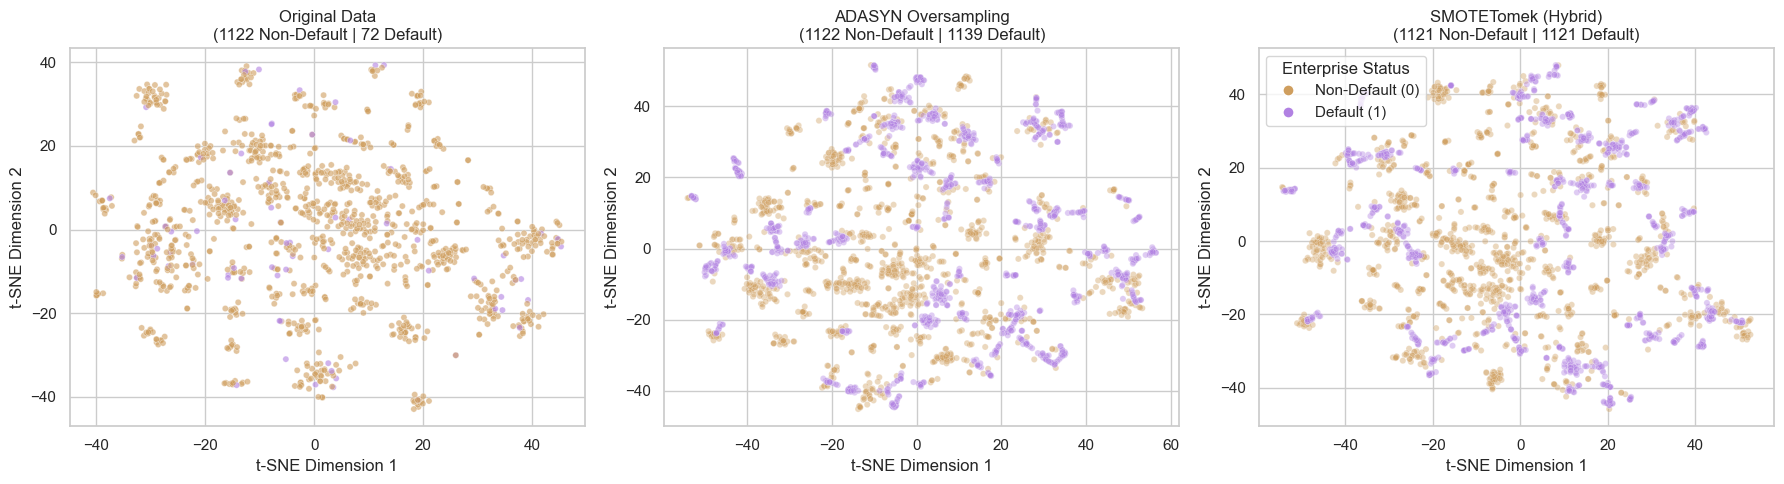

In [16]:
# PLOT THE RESULTS

# Set up a 1x3 grid for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Define a consistent color palette: Gold for Non-Default (0), Purple for Default (1)
colors = {0: "#CF9E5E", 1: "#B181E2"} 

# Plot A: Original Imbalanced Data
sns.scatterplot(
    x=X_tsne_orig[:, 0], y=X_tsne_orig[:, 1], hue=y_train, 
    palette=colors, alpha=0.6, s=20, ax=axes[0], legend=False
)
axes[0].set_title(f'Original Data\n({sum(y_train==0)} Non-Default | {sum(y_train==1)} Default)', fontsize=12)
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')

# Plot B: ADASYN Data
sns.scatterplot(
    x=X_tsne_ada[:, 0], y=X_tsne_ada[:, 1], hue=y_train_ada, 
    palette=colors, alpha=0.4, s=20, ax=axes[1], legend=False
)
axes[1].set_title(f'ADASYN Oversampling\n({sum(y_train_ada==0)} Non-Default | {sum(y_train_ada==1)} Default)', fontsize=12)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

# Plot C: SMOTETomek Data
sns.scatterplot(
    x=X_tsne_smt[:, 0], y=X_tsne_smt[:, 1], hue=y_train_smt, 
    palette=colors, alpha=0.4, s=20, ax=axes[2]
)
axes[2].set_title(f'SMOTETomek (Hybrid)\n({sum(y_train_smt==0)} Non-Default | {sum(y_train_smt==1)} Default)', fontsize=12)
axes[2].set_xlabel('t-SNE Dimension 1')
axes[2].set_ylabel('t-SNE Dimension 2')

# Custom legend for the final plot
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markersize=8, label='Non-Default (0)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[1], markersize=8, label='Default (1)')
]
axes[2].legend(handles=handles, title="Enterprise Status", loc='best')

plt.tight_layout()
plt.show()

# **Selection Logic**

In [17]:
if f1_smt >= f1_ada:
    print("SMOTETomek performed better. Saving SMOTETomek data.")
    X_train_final, y_train_final = X_train_smt, y_train_smt
    winner = "SMOTETomek"
else:
    print("ADASYN performed better. Saving ADASYN data.")
    X_train_final, y_train_final = X_train_ada, y_train_ada
    winner = "ADASYN"

SMOTETomek performed better. Saving SMOTETomek data.


# **Saving Train, Test and Validation Sets**

In [18]:
print("\n--- Finalizing Dynamic Selection & Saving ---")

# DYNAMIC SELECTION LOGIC

# Automatically compare the F1 scores. 
# If it's a tie, it defaults to SMOTETomek (>=) because of its boundary cleaning properties.

if f1_smt >= f1_ada:
    print(f"SMOTETomek selected! (Score: {f1_smt:.4f} vs ADASYN: {f1_ada:.4f})")
    winner = "SMOTETomek"
    X_train_ready = X_train_smt
    y_train_ready = y_train_smt
else:
    print(f"ADASYN selected! (Score: {f1_ada:.4f} vs SMOTETomek: {f1_smt:.4f})")
    winner = "ADASYN"
    X_train_ready = X_train_ada
    y_train_ready = y_train_ada

# DIRECTORY SETUP
output_dir = "MSME_Processed_Data"
os.makedirs(output_dir, exist_ok=True)

# SAVE ONLY THE WINNING DATA

# Training Data (Only the one chosen by the logic above)
X_train_ready.to_csv(os.path.join(output_dir, 'X_train_ready.csv'), index=False)
y_train_ready.to_csv(os.path.join(output_dir, 'y_train_ready.csv'), index=False)

# Validation & Test Data (Always saved, as they are real, unseen data)
X_val_final.to_csv(os.path.join(output_dir, 'X_val_ready.csv'), index=False)
y_val.to_csv(os.path.join(output_dir, 'y_val_ready.csv'), index=False)

X_test_final.to_csv(os.path.join(output_dir, 'X_test_ready.csv'), index=False)
y_test.to_csv(os.path.join(output_dir, 'y_test_ready.csv'), index=False)

# Document the scores and the winner in the text file
with open(os.path.join(output_dir, 'resampling_winner.txt'), 'w') as f:
    f.write(f"The best performing method selected for XGBoost was: {winner}\n")
    f.write(f"SMOTETomek F1-Score: {f1_smt:.4f}\n")
    f.write(f"ADASYN F1-Score: {f1_ada:.4f}\n")

print(f"Pipeline Complete! Only the {winner} training data was saved to '{output_dir}'.")


--- Finalizing Dynamic Selection & Saving ---
SMOTETomek selected! (Score: 0.0000 vs ADASYN: 0.0000)
Pipeline Complete! Only the SMOTETomek training data was saved to 'MSME_Processed_Data'.
